# Long Short-Term Memory in Pytorch

In [ ]:
import yfinance as yf

import numpy as np
import matplotlib.pyplot as plt

import torch
import torch.nn as nn
import torch.optim as optim

from sklearn.preprocessing import MinMaxScaler
from sklearn.metrics import root_mean_squared_error

In [64]:
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(f"Using device: {device}")

Using device: cuda


In [65]:
torch.backends.cudnn.enabled = False

## Loading Data

In [66]:
ticker = 'AAPL'
df = yf.download(ticker, '2020-01-01')
print(df)

[*********************100%***********************]  1 of 1 completed

Price            Close        High         Low        Open     Volume
Ticker            AAPL        AAPL        AAPL        AAPL       AAPL
Date                                                                 
2020-01-02   72.333862   72.394070   71.091169   71.344039  135480400
2020-01-03   71.630653   72.389273   71.406681   71.563221  146322800
2020-01-06   72.201424   72.239958   70.503561   70.754028  118387200
2020-01-07   71.861855   72.466338   71.642697   72.211056  108872000
2020-01-08   73.017830   73.318870   71.565614   71.565614  132079200
...                ...         ...         ...         ...        ...
2026-06-04  311.230011  313.540009  309.649994  313.230011   44869100
2026-06-05  307.339996  315.170013  307.149994  312.859985   65310500
2026-06-08  301.540009  317.399994  301.170013  308.739990   77949100
2026-06-09  290.549988  300.750000  287.779999  300.279999   70108800
2026-06-10  291.579987  294.750000  287.380005  290.739990   52608100

[1618 rows x 5 colu

<Axes: xlabel='Date'>

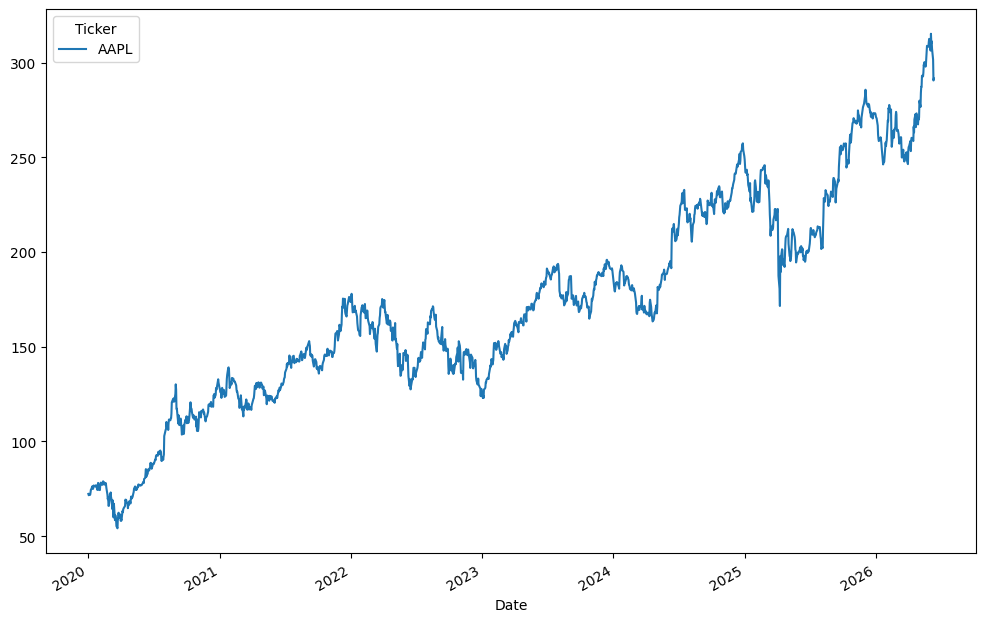

In [67]:
df.Close.plot(figsize=(12, 8))

## Data Preprocessing

In [68]:
scaler = MinMaxScaler(feature_range=(-1, 1))

df['Close'] = scaler.fit_transform(df['Close'])
print(df['Close'])

Ticker          AAPL
Date                
2020-01-02 -0.860784
2020-01-03 -0.866172
2020-01-06 -0.861799
2020-01-07 -0.864401
2020-01-08 -0.855544
...              ...
2026-06-04  0.969583
2026-06-05  0.939778
2026-06-08  0.895340
2026-06-09  0.811137
2026-06-10  0.819029

[1618 rows x 1 columns]


In [69]:
seq_length = 50
data = []

for i in range(len(df) - seq_length):
    data.append(df['Close'][i:i+seq_length])

data = np.array(data)

train_size = int(0.8 * len(data))

X_train = torch.from_numpy(data[:train_size, :-1, :]).type(torch.Tensor).to(device)
y_train = torch.from_numpy(data[:train_size, -1, :]).type(torch.Tensor).to(device)
X_test = torch.from_numpy(data[train_size:, :-1, :]).type(torch.Tensor).to(device)
y_test = torch.from_numpy(data[train_size:, -1, :]).type(torch.Tensor).to(device)

## Creating LSTM Model

In [70]:
class PredictionModel(nn.Module):
    def __init__(self, input_dim, hidden_dim, num_layers, output_dim):
        super().__init__()
        
        self.num_layers = num_layers
        self.hidden_dim = hidden_dim

        self.lstm = nn.LSTM(input_dim, hidden_dim, num_layers, batch_first=True, dropout=0.2)
        self.fc = nn.Linear(hidden_dim, output_dim)

    def forward(self, x):
        h0 = torch.zeros(self.num_layers, x.size(0), self.hidden_dim, device=device)
        c0 = torch.zeros(self.num_layers, x.size(0), self.hidden_dim, device=device)

        out, (hn, cn) = self.lstm(x, (h0.detach(), c0.detach()))
        out = self.fc(out[:, -1, :])

        return out

In [71]:
model = PredictionModel(input_dim=1, hidden_dim=32, num_layers=2, output_dim=1).to(device)
loss_function = nn.MSELoss()
optimiser = optim.Adam(model.parameters(), lr=0.01)

## Training Model

In [72]:
for epoch in range(200):
    y_train_pred = model(X_train)

    loss = loss_function(y_train_pred, y_train)

    if (epoch + 1) % 25 == 0:
        print(f"Epoch {epoch + 1} loss: {loss}")

    optimiser.zero_grad()
    loss.backward()
    optimiser.step()

Epoch 25 loss: 0.005229299422353506
Epoch 50 loss: 0.0018513873219490051
Epoch 75 loss: 0.0014648002106696367
Epoch 100 loss: 0.001364249619655311
Epoch 125 loss: 0.0013424475910142064
Epoch 150 loss: 0.0012653226731345057
Epoch 175 loss: 0.0011538144899532199
Epoch 200 loss: 0.0011165214236825705


## Model Evaluation

In [73]:
model.eval()

y_test_pred = model(X_test)

y_train_pred = scaler.inverse_transform(y_train_pred.detach().cpu().numpy())
y_train = scaler.inverse_transform(y_train.detach().cpu().numpy())
y_test_pred = scaler.inverse_transform(y_test_pred.detach().cpu().numpy())
y_test = scaler.inverse_transform(y_test.detach().cpu().numpy())

In [74]:
train_rmse = root_mean_squared_error(y_train[:, 0], y_train_pred[:, 0])
test_rmse = root_mean_squared_error(y_test[:, 0], y_test_pred[:, 0])
print(f"Train RMSE: {train_rmse}")
print(f"Test RMSE: {test_rmse}")

Train RMSE: 4.361184120178223
Test RMSE: 8.95942211151123


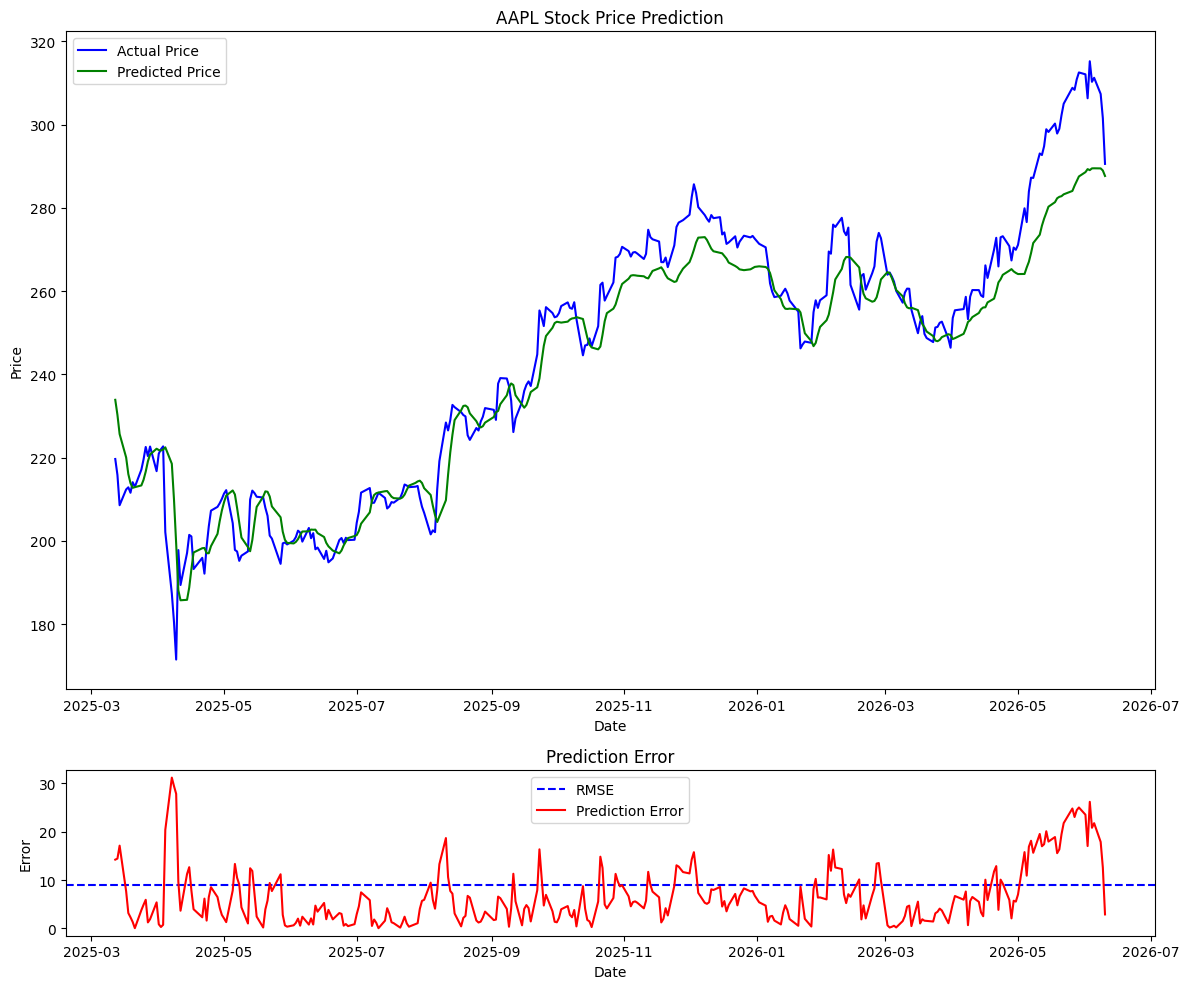

In [75]:
fig = plt.figure(figsize=(12, 10))

gs = fig.add_gridspec(4, 1)

ax1 = fig.add_subplot(gs[:3, 0])
ax1.plot(df.iloc[-len(y_test):].index, y_test, color='blue', label='Actual Price')
ax1.plot(df.iloc[-len(y_test):].index, y_test_pred, color='green', label='Predicted Price')
ax1.legend()
plt.title(f"{ticker} Stock Price Prediction")
plt.xlabel('Date')
plt.ylabel('Price')

ax2 = fig.add_subplot(gs[3, 0])
ax2.axhline(test_rmse, color='blue', linestyle='--', label='RMSE')
ax2.plot(df[-len(y_test):].index, abs(y_test - y_test_pred), 'r', label='Prediction Error')
ax2.legend()
plt.title("Prediction Error")
plt.xlabel("Date")
plt.ylabel("Error")
plt.tight_layout()

plt.show()